In [ ]:
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from transformers import LogitsProcessor
import numpy as np
from tqdm import tqdm

In [ ]:
class summarizeee:
    def __init__(self):
        self.tokenizer = AutoTokenizer.from_pretrained(
          "facebook/bart-large-cnn"
        )
        self.model = AutoModelForSeq2SeqLM.from_pretrained(
          "facebook/bart-large-cnn",
          dtype=torch.float16,
          device_map="auto"
        )

    def summarize(self, text, max_length = 1024):
        input_ids = self.tokenizer(
          text,
          return_tensors="pt",
          padding="max_length",
          truncation=True,
          max_length=max_length
        ).to(self.model.device)
        output = self.model.generate(
          **input_ids,
          max_length=1024,
          do_sample=True,
          temperature=1.0,
          num_beams=1,
    )
        return self.tokenizer.decode(output[0], skip_special_tokens=True)

In [ ]:
summary = summarizeee()
article = """summarize in 1000 words: Throughout high school, I had always excelled in academics. My mother is a college professor and my father is a teacher, so learning was instilled in me at a very young age. During my junior year (a monumental year for future college students), I faced a significant setback when I received a failing grade on a crucial exam in a class that I had always done fairly well in.

A failure.

That's exactly how I felt.

I let my parents down and more importantly, myself. Overwhelmed with insecurity and self-doubt, I went the entire day in shock and questioned how this would affect my future in higher education. Was I even cut out for the academic rigor of college? Before I began to spiral, I sought out comfort from my parents and guidance counselor. With their grace and understanding, they pulled me from the depths of devastation and I quickly realized I would be okay.

Yes, a failing grade on an important exam is crushing, but I could work hard and tutor for the rest of the school year to prevent it from happening again and save my grade in the class.

I realized that failures are a part of life and that it is how we react to them that determines our success. I also learned the importance of seeking help and support from others. By working with my teacher and tutor, I was able to gain a deeper understanding of the subject and improve my grades. And, of course, I learned to persevere in the face of adversity, no matter how big my problem seemed at the current moment. This experience was a turning point in my high school career and helped to shape the person I am today. I am grateful for the lessons I learned and the growth that came from this challenge."""

s = summary.summarize(article)
print(s)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Katherine Hintz received a failing grade on a crucial exam in her high school class. Before spiral began, she sought out comfort from her parents and guidance counselor.Hintz: I realized that failures are a part of life and that it is how we react to them that determines our success.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("cnn_dailymail", "3.0.0")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})


In [ ]:
example = dataset['validation'][2]
print("Article:", example['article'][:5000], "...")
summar = summarizeee()
l = summar.summarize(example['article'])
print("Summary:", l)

Article: (CNN)French striker Bafetimbi Gomis, who has a history of fainting, said he is now "feeling well" after collapsing during Swansea's 3-2 loss at Tottenham in the Premier League on Wednesday. The worrying incident occurred in the first half at White Hart Lane -- after Tottenham scored in the seventh minute -- but the 29-year-old left the pitch conscious following about five minutes of treatment. The Guardian added that he was wearing an oxygen mask. Play was temporarily stopped before resuming. As the match progressed, Swansea tweeted that Gomis was "fine," with manager Garry Monk using the same word to describe Gomis' condition. Gomis spent the night in hospital as a precaution, Swansea said on its website. "I wanted to reassure you concerning my health," Gomis told the website. "It actually looks much scarier than it is physically dangerous, and I am feeling well now. "I have been under a great deal of stress and fatigue due to my father's health, which requires me to go back 

In [ ]:
class WatermarkLogitsWarper(LogitsProcessor):
    def __init__(self, vocab_size, gamma=0.5, delta=5.0, seeding="simple"):
        self.vocab_size = vocab_size
        self.gamma = gamma
        self.delta = delta
        self.seeding = seeding
        self.green_list_size = int(gamma * vocab_size)

        print(f"Watermark initialized: γ={gamma}, δ={delta}")
        print(f"Vocabulary size: {vocab_size}")
        print(f"Green list size: {self.green_list_size} ({gamma*100:.0f}% of vocab)")

    def _get_greenlist_ids(self, input_ids):
        if input_ids.shape[-1] == 0:
            prev_token = 0
        else:
            prev_token = input_ids[0, -1].item()
        rng = torch.Generator()
        rng.manual_seed(prev_token)
        vocab_permutation = torch.randperm(self.vocab_size, generator=rng)
        greenlist_ids = vocab_permutation[:self.green_list_size]
        greenlist_ids = greenlist_ids.to(input_ids.device)

        return greenlist_ids

    def __call__(self, input_ids, scores):
        greenlist_ids = self._get_greenlist_ids(input_ids)
        actual_vocab_size = scores.shape[-1]
        greenlist_ids = greenlist_ids[greenlist_ids < actual_vocab_size]
        green_mask = torch.zeros_like(scores, dtype=torch.bool)
        green_mask[:, greenlist_ids] = True
        scores = torch.where(green_mask, scores + self.delta, scores)

        return scores

In [ ]:
summary = summarizeee()
article = dataset['validation'][2]['article']

# Tokenize
input_ids = summary.tokenizer(
    article,
    return_tensors="pt",
    padding="max_length",
    truncation=True,
    max_length=1024
).to(summary.model.device)

# Using watermark
watermark = WatermarkLogitsWarper(
    vocab_size=len(summary.tokenizer),
    gamma=0.5,
    delta=5.0
)

# Generating with watermark
output = summary.model.generate(
    **input_ids,
    max_length=1024,
    do_sample=True,
    temperature=1.0,
    num_beams=1,
    logits_processor=[watermark]
)

watermarked_text = summary.tokenizer.decode(output[0], skip_special_tokens=True)
print(watermarked_text)

Watermark initialized: γ=0.5, δ=5.0
Vocabulary size: 50265
Green list size: 25132 (50% of vocab)
French striker Bafetimbi Gomis says he is "feeling well." He collapses on the floor at White Hart Street during Swansea's 3-2 loss to Tottenham on Wednesday. Gomes has suffered similar problems in France. He will not complete his fitness and fitness testing, Swansea's manager says Today.


In [ ]:
bart_summary = """Bafetimbi Gomis says he is "feising well" after collapsing during Swansea's match. He spent the night in hospital ahead of Swansea's 3-2 defeat at Tottenham. Swansea tweeted early on that Gomatis was "fine" Gomus has a habit of fainting and was wearing an oxygen mask when he collapsed."""

bart_watermark = """Bfetimbi Togo Gomis joins list of footballers who have fallen on the turf. French striker says he is "feeling well", adding, "I wanted to reassured ... my health" Gogum is " fine," says Swansea boss Garry Monk. The 29-year-old had a history of fainting in France."""


In [ ]:
class WatermarkDetector:

    def __init__(self, tokenizer, gamma=0.5, z_threshold=4.0):

        self.tokenizer = tokenizer
        self.vocab_size = len(tokenizer)
        self.gamma = gamma
        self.z_threshold = z_threshold
        self.green_list_size = int(gamma * self.vocab_size)

        print(f"Detector initialized: γ={gamma}, z_threshold={z_threshold}")
        print(f"Vocabulary size: {self.vocab_size}")

    def _get_greenlist_ids(self, prev_token):

        rng = torch.Generator()
        rng.manual_seed(prev_token)
        vocab_permutation = torch.randperm(self.vocab_size, generator=rng)
        greenlist_ids = vocab_permutation[:self.green_list_size]
        return set(greenlist_ids.tolist())

    def detect(self, text):
        tokens = self.tokenizer.encode(text, add_special_tokens=False)
        if len(tokens) < 2:
            return {
                'z_score': 0,
                'p_value': 1.0,
                'is_watermarked': False,
                'num_green': 0,
                'total_tokens': 0,
                'green_fraction': 0
            }

        num_green = 0

        for i in range(1, len(tokens)):
            prev_token = tokens[i-1]
            current_token = tokens[i]
            greenlist = self._get_greenlist_ids(prev_token)
            if current_token in greenlist:
                num_green += 1

        T = len(tokens) - 1
        expected_green = self.gamma * T
        variance = T * self.gamma * (1 - self.gamma)
        std_dev = variance ** 0.5
        if std_dev == 0:
            z_score = 0
        else:
            z_score = (num_green - expected_green) / std_dev
        from scipy.stats import norm
        p_value = 1 - norm.cdf(z_score)
        is_watermarked = z_score > self.z_threshold

        return {
            'z_score': z_score,
            'p_value': p_value,
            'is_watermarked': is_watermarked,
            'num_green': num_green,
            'total_tokens': T,
            'green_fraction': num_green / T if T > 0 else 0
        }

In [ ]:
detector = WatermarkDetector(summary.tokenizer, gamma=0.5, z_threshold=4.0)

bart_result = detector.detect(bart_summary)
watermarked_result = detector.detect(bart_watermark)
print('From BART:',bart_summary)
print('Watermarked Text:',bart_watermark)

print(f"Bart Z-score: {bart_result['z_score']:.2f} | Green: {bart_result['num_green']}/{bart_result['total_tokens']} ({bart_result['green_fraction']*100:.1f}%)")
print(f"Watermarked Z-score: {watermarked_result['z_score']:.2f} | Green: {watermarked_result['num_green']}/{watermarked_result['total_tokens']} ({watermarked_result['green_fraction']*100:.1f}%)")

print(f"\nBart detected: {bart_result['is_watermarked']}")
print(f"Watermarked detected: {watermarked_result['is_watermarked']}")

Detector initialized: γ=0.5, z_threshold=4.0
Vocabulary size: 50265
From BART: Bafetimbi Gomis says he is "feising well" after collapsing during Swansea's match. He spent the night in hospital ahead of Swansea's 3-2 defeat at Tottenham. Swansea tweeted early on that Gomatis was "fine" Gomus has a habit of fainting and was wearing an oxygen mask when he collapsed.
Watermarked Text: Bfetimbi Togo Gomis joins list of footballers who have fallen on the turf. French striker says he is "feeling well", adding, "I wanted to reassured ... my health" Gogum is " fine," says Swansea boss Garry Monk. The 29-year-old had a history of fainting in France.
Bart Z-score: 0.36 | Green: 37/71 (52.1%)
Watermarked Z-score: 6.69 | Green: 63/70 (90.0%)

Bart detected: False
Watermarked detected: True


In [ ]:
summary = summarizeee()
detector = WatermarkDetector(summary.tokenizer, gamma=0.5, z_threshold=4.0)
num_examples = 100
test_articles = dataset['validation'][:num_examples]

Detector initialized: γ=0.5, z_threshold=4.0
Vocabulary size: 50265


In [ ]:
results = []

In [ ]:
for i in tqdm(range(num_examples), desc="Processing articles"):
    article = test_articles['article'][i]
    reference = test_articles['highlights'][i]

    try:
        # Generate baseline summary
        bart = summary.summarize(article)

        # Generate watermarked summary
        input_ids = summary.tokenizer(
            article,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=1024
        ).to(summary.model.device)

        watermark = WatermarkLogitsWarper(
            vocab_size=len(summary.tokenizer),
            gamma=0.5,
            delta=5.0
        )

        output = summary.model.generate(
            **input_ids,
            max_length=1024,
            do_sample=True,
            temperature=1.0,
            num_beams=1,
            logits_processor=[watermark]
        )

        watermarked = summary.tokenizer.decode(output[0], skip_special_tokens=True)

        # Detect watermark in both
        bart_detection = detector.detect(bart)
        watermarked_detection = detector.detect(watermarked)

        # Store results (MINIMAL - paper metrics only)
        results.append({
            'article_id': i,
            'bart_z': bart_detection['z_score'],
            'bart_detected': bart_detection['is_watermarked'],
            'watermarked_z': watermarked_detection['z_score'],
            'watermarked_detected': watermarked_detection['is_watermarked'],
            'bart_text': bart,
            'watermarked_text': watermarked,
            'reference': reference
        })

    except Exception as e:
        print(f"\nError on article {i}: {e}")
        continue
print("\n Processing complete!")

Processing articles:   0%|          | 0/100 [00:00<?, ?it/s]

Watermark initialized: γ=0.5, δ=5.0
Vocabulary size: 50265
Green list size: 25132 (50% of vocab)


Processing articles:   1%|          | 1/100 [00:02<03:26,  2.08s/it]

Watermark initialized: γ=0.5, δ=5.0
Vocabulary size: 50265
Green list size: 25132 (50% of vocab)


Processing articles:   2%|▏         | 2/100 [00:03<03:14,  1.99s/it]

...

Watermark initialized: γ=0.5, δ=5.0
Vocabulary size: 50265
Green list size: 25132 (50% of vocab)


Processing articles:  99%|█████████▉| 99/100 [03:34<00:01,  1.93s/it]

Watermark initialized: γ=0.5, δ=5.0
Vocabulary size: 50265
Green list size: 25132 (50% of vocab)


Processing articles: 100%|██████████| 100/100 [03:36<00:00,  2.16s/it]


 Processing complete!


In [ ]:
print("DETECTION PERFORMANCE METRICS")

bart_z_scores = [r['bart_z'] for r in results]
watermarked_z_scores = [r['watermarked_z'] for r in results]
bart_detected_count = sum([r['bart_detected'] for r in results])
watermarked_detected_count = sum([r['watermarked_detected'] for r in results])
total = len(results)

True_positives = watermarked_detected_count / total
False_positives = bart_detected_count / total

print(f"\n📊 DETECTION RATES (n={total}):")
print(f"  True Positive Rate (TPR):  {True_positives:.2%}")
print(f"  False Positive Rate (FPR): {False_positives:.2%}")

print(f"\n📈 Z-SCORES:")
print(f"BART (no watermark):")
print(f"  Mean: {np.mean(bart_z_scores):.2f} ± {np.std(bart_z_scores):.2f}")

print(f"\nWatermarked (γ=0.5, δ=5.0):")
print(f"  Mean: {np.mean(watermarked_z_scores):.2f} ± {np.std(watermarked_z_scores):.2f}")

DETECTION PERFORMANCE METRICS

📊 DETECTION RATES (n=100):
  True Positive Rate (TPR):  100.00%
  False Positive Rate (FPR): 0.00%

📈 Z-SCORES:
BART (no watermark):
  Mean: -0.02 ± 0.95

Watermarked (γ=0.5, δ=5.0):
  Mean: 6.65 ± 0.80


In [ ]:
print("Z-SCORE DISTRIBUTION ANALYSIS")
strong_watermark = sum([1 for z in watermarked_z_scores if z >= 6])
good_watermark = sum([1 for z in watermarked_z_scores if 4 <= z < 6])
weak_watermark = sum([1 for z in watermarked_z_scores if 2 <= z < 4])
no_watermark = sum([1 for z in watermarked_z_scores if z < 2])
print(f"\nWatermarked Z-Score")
print(f"  Strong (z ≥ 6):    {strong_watermark}/{total} ({strong_watermark/total:.1%})")
print(f"  Good (4 ≤ z < 6):  {good_watermark}/{total} ({good_watermark/total:.1%})")
print(f"  Weak (2 ≤ z < 4):  {weak_watermark}/{total} ({weak_watermark/total:.1%})")
print(f"  None (z < 2):      {no_watermark}/{total} ({no_watermark/total:.1%})")
false_negatives = [r for r in results if not r['watermarked_detected']]
if false_negatives:
    print(f"\n⚠️ FALSE NEGATIVES ({len(false_negatives)} cases):")
    for fn in false_negatives[:5]:  # Show first 5
        print(f"  Article {fn['article_id']}: z={fn['watermarked_z']:.2f}")

# Find false positives
false_positives = [r for r in results if r['bart_detected']]
if false_positives:
    print(f"\n⚠️ FALSE POSITIVES ({len(false_positives)} cases):")
    for fp in false_positives[:5]:  # Show first 5
        print(f"  Article {fp['article_id']}: z={fp['bart_z']:.2f}")

Z-SCORE DISTRIBUTION ANALYSIS

Watermarked Z-Score
  Strong (z ≥ 6):    77/100 (77.0%)
  Good (4 ≤ z < 6):  23/100 (23.0%)
  Weak (2 ≤ z < 4):  0/100 (0.0%)
  None (z < 2):      0/100 (0.0%)



GENERATING VISUALIZATION
✅ Visualization saved: watermark_z_scores.png


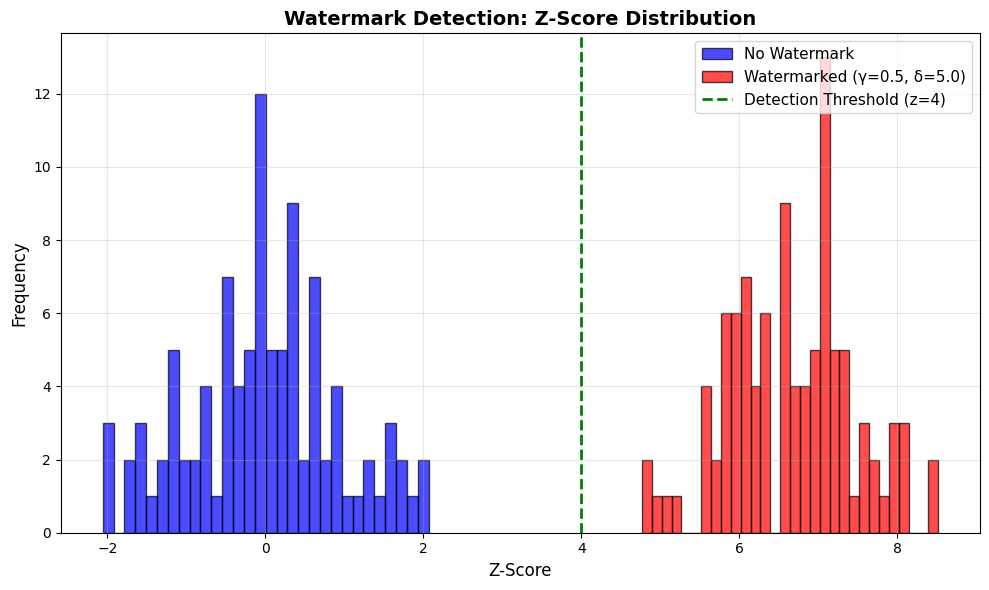

In [ ]:
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("GENERATING VISUALIZATION")
print("="*80)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.hist(bart_z_scores, bins=30, alpha=0.7, label='No Watermark', color='blue', edgecolor='black')
ax.hist(watermarked_z_scores, bins=30, alpha=0.7, label='Watermarked (γ=0.5, δ=5.0)', color='red', edgecolor='black')
ax.axvline(x=4.0, color='green', linestyle='--', linewidth=2, label='Detection Threshold (z=4)')
ax.set_xlabel('Z-Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Watermark Detection: Z-Score Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('watermark_z_scores.png', dpi=300, bbox_inches='tight')  # ← Changed
print("✅ Visualization saved: watermark_z_scores.png")
plt.show()

In [ ]:
print(f"""
EXPERIMENT CONFIGURATION:
  Model: facebook/bart-large-cnn
  Dataset: CNN
  Samples tested: {total}
  Watermark parameters: γ=0.5, δ=5.0
  Detection threshold: z > 4.0

DETECTION PERFORMANCE:
  True Positive Rate (TPR):  {True_positives:.1%}
  False Positive Rate (FPR): {False_positives:.1%}

Z-SCORE ANALYSIS:
  BART:        {np.mean(bart_z_scores):.2f} ± {np.std(bart_z_scores):.2f}
  Watermarked: {np.mean(watermarked_z_scores):.2f} ± {np.std(watermarked_z_scores):.2f}

RESULT: {"✅ SUCCESS" if True_positives > 0.95 and False_positives < 0.05 else "⚠️ NEEDS TUNING"}
""")


EXPERIMENT CONFIGURATION:
  Model: facebook/bart-large-cnn
  Dataset: CNN
  Samples tested: 100
  Watermark parameters: γ=0.5, δ=5.0
  Detection threshold: z > 4.0

DETECTION PERFORMANCE:
  True Positive Rate (TPR):  100.0%
  False Positive Rate (FPR): 0.0%

Z-SCORE ANALYSIS:
  BART:        -0.02 ± 0.95
  Watermarked: 6.65 ± 0.80

RESULT: ✅ SUCCESS



In [ ]:
pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=291c3f19bad3b7113fec640381e59b7a5db4df5861cb3a39d8043939c7a5e385
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:
from rouge_score import rouge_scorer

# Initialize ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

print("\nROUGE scores")
bart_rouge1 = []
bart_rouge2 = []
bart_rougeL = []
watermarked_rouge1 = []
watermarked_rouge2 = []
watermarked_rougeL = []

for result in tqdm(results, desc="Computing ROUGE"):
    reference = result['reference']
    bart_text = result['bart_text']
    watermarked_text = result['watermarked_text']
    bart_scores = scorer.score(reference, bart_text)
    bart_rouge1.append(bart_scores['rouge1'].fmeasure)
    bart_rouge2.append(bart_scores['rouge2'].fmeasure)
    bart_rougeL.append(bart_scores['rougeL'].fmeasure)
    watermarked_scores = scorer.score(reference, watermarked_text)
    watermarked_rouge1.append(watermarked_scores['rouge1'].fmeasure)
    watermarked_rouge2.append(watermarked_scores['rouge2'].fmeasure)
    watermarked_rougeL.append(watermarked_scores['rougeL'].fmeasure)
print(f"\nROUGE-1:")
print(f"  BART:        {np.mean(bart_rouge1):.3f}")
print(f"  Watermarked: {np.mean(watermarked_rouge1):.3f}")
print(f"\nROUGE-2:")
print(f"  BART:        {np.mean(bart_rouge2):.3f}")
print(f"  Watermarked: {np.mean(watermarked_rouge2):.3f}")
print(f"\nROUGE-L:")
print(f"  BART:        {np.mean(bart_rougeL):.3f}")
print(f"  Watermarked: {np.mean(watermarked_rougeL):.3f}")


ROUGE scores


Computing ROUGE: 100%|██████████| 100/100 [00:02<00:00, 49.06it/s]


ROUGE-1:
  BART:        0.326
  Watermarked: 0.261

ROUGE-2:
  BART:        0.123
  Watermarked: 0.053

ROUGE-L:
  BART:        0.222
  Watermarked: 0.169


In [ ]:
print(f"""
CONFIGURATION:
  Model: BART-large-CNN
  Dataset: CNN/DailyMail (n={total})
  Watermark: γ=0.5, δ=5.0

DETECTION:
  TPR: {True_positives:.1%}
  FPR: {False_positives:.1%}

  Z-scores:
    BART:        {np.mean(bart_z_scores):.2f} ± {np.std(bart_z_scores):.2f}
    Watermarked: {np.mean(watermarked_z_scores):.2f} ± {np.std(watermarked_z_scores):.2f}

QUALITY (ROUGE):
  ROUGE-1:  {np.mean(bart_rouge1):.3f} → {np.mean(watermarked_rouge1):.3f}
  ROUGE-2:  {np.mean(bart_rouge2):.3f} → {np.mean(watermarked_rouge2):.3f}
  ROUGE-L:  {np.mean(bart_rougeL):.3f} → {np.mean(watermarked_rougeL):.3f}
""")


CONFIGURATION:
  Model: BART-large-CNN
  Dataset: CNN/DailyMail (n=100)
  Watermark: γ=0.5, δ=5.0

DETECTION:
  TPR: 100.0%
  FPR: 0.0%
  
  Z-scores:
    BART:        -0.02 ± 0.95
    Watermarked: 6.65 ± 0.80

QUALITY (ROUGE):
  ROUGE-1:  0.326 → 0.261
  ROUGE-2:  0.123 → 0.053
  ROUGE-L:  0.222 → 0.169

